<p style="padding: 10px; border: 1px solid black;">
<img src="../mlu_utils/images/MLU-NEW-logo.png" alt="drawing" width="400"/> <br/>
<div style="background-color: #1A5276; padding: 20px; border-radius: 10px; text-align: center; margin-bottom: 30px;">
    <h1 style="color: white; margin: 0;">MLU: Building Applications with Foundation Models</h1>
    <h2 style="color: white; margin-top: 15px;">Lab 4b: Troubleshooting</h2>
</div>

<!-- Compact Lab Introduction with Activity/Challenge Explanation -->
<div style="background-color: #F8F9F9; padding: 15px; border-radius: 5px; margin: 20px 0;">
    <h4 style="color: #2E4053; margin-top: 0;">About This Lab</h4>
    <p>Throughout this lab, you will encounter two types of interactive elements:</p>
    <table style="width: 100%; border-collapse: collapse; margin: 15px 0;">
        <tr>
            <td style="text-align: center; padding: 10px; width: 50%;">
                <img src="../mlu_utils/images/activity.png" alt="Activity" width="125"/>
            </td>
            <td style="text-align: center; padding: 10px; width: 50%;">
                <img src="../mlu_utils/images/challenge.png" alt="Challenge" width="125"/>
            </td>
        </tr>
        <tr>
            <td style="text-align: center; padding: 10px; background-color: #EBF5FB;">
                <p>No coding is needed for an activity. You try to understand a concept, <br/>answer questions, or run a code cell.</p>
            </td>
            <td style="text-align: center; padding: 10px; background-color: #FEF9E7;">
                <p>Challenges are where you test your understanding by implementing something new or taking a short quiz.</p>
            </td>
        </tr>
    </table>
    <p>Please work through this notebook from top to bottom to avoid errors due to missing code or context.</p>
</div>

<!-- Table of Contents with All Section Levels -->
<div style="background-color: #EBF5FB; padding: 15px; border-radius: 5px; margin-bottom: 30px;">
    <h2 style="color: #2874A6; border-bottom: 1px solid #2874A6; padding-bottom: 5px;">Table of Contents</h2>
    <p><a href="#section1" style="color: #2E86C1; font-weight: bold; text-decoration: none;">1. Installing dependencies</a></p>
    <p><a href="#section2" style="color: #2E86C1; font-weight: bold; text-decoration: none;">2. Create a RAG workflow</a></p>
    <ul style="margin-top: 0; padding-left: 30px;">
        <li><a href="#section2-1" style="color: #3498DB; text-decoration: none;">2.1 Load documents</a></li>
        <li><a href="#section2-2" style="color: #3498DB; text-decoration: none;">2.2 Define the vector stores</a></li>
        <li><a href="#section2-3" style="color: #3498DB; text-decoration: none;">2.3 Generate multimodal embeddings</a></li>
        <li><a href="#section2-4" style="color: #3498DB; text-decoration: none;">2.4 Multimodal prompting with retrieval</a></li>
    </ul>
    <p><a href="#section3" style="color: #2E86C1; font-weight: bold; text-decoration: none;">3. Troubleshoot issues with text prompts</a></p>
    <p><a href="#section4" style="color: #2E86C1; font-weight: bold; text-decoration: none;">4. Troubleshoot issues with multimodal prompts</a></p>
    <p><a href="#section5" style="color: #2E86C1; font-weight: bold; text-decoration: none;">5. Quizzes</a></p>
</div>

In this lab, we will explore the power of multimodal models, such as Amazon Nova Lite, for troubleshooting common issues with Echo devices. Multimodal models combine multiple input modalities, such as text and images, to provide more comprehensive and intuitive solutions. By leveraging both textual descriptions and visual representations of the issues, you can streamline the troubleshooting process and enhance the user experience.

Traditional text-based approaches often fall short in providing comprehensive solutions, leaving users frustrated and unable to fully resolve their problems. In this lab, we will explore how to use multimodal models, such as Amazon Nova Lite, to troubleshoot common issues with Echo devices.

Being able to submit both text and images to a multimodal model simplifies and enhances an automated troubleshooting process, providing the users with more comprehensive and effective solutions.

<!-- Section Header -->
<div id="section1" style="border-left: 5px solid #3498DB; padding-left: 15px; margin: 40px 0 20px 0;">
    <h2 style="color: #2874A6;">1. Installing dependencies</h2>
</div>

In [1]:
!pip install -q -r ../requirements.txt

Let's import the libraries and modules required for this lab. We will import the `invoke_nova_lite_multimodal`, `prepare_image`, and `get_base64_encoded_image` functions we defined and used in previous labs.

In [2]:
import sys
sys.path.append('..')

import boto3
import os
import json
from IPython.display import Image, display, Markdown, IFrame

from mlu_utils.multimodal_utils import invoke_nova_lite_multimodal, prepare_image, get_base64_encoded_image

<!-- Section Header -->
<div id="section2" style="border-left: 5px solid #3498DB; padding-left: 15px; margin: 40px 0 20px 0;">
    <h2 style="color: #2874A6;">2. Create a RAG workflow</h2>
</div>

RAG workflows combine the strengths of retrieval systems and generative language models, enabling them to provide accurate and relevant responses by leveraging external knowledge sources. The application will be developed using the following steps:

1. We have curated a collection of troubleshooting documents related to Echo devices from the [website](https://www.amazon.com/gp/help/customer/display.html?nodeId=201399130). These documents will serve as our knowledge base, containing  information about common issues, solutions, and best practices for troubleshooting Echo devices.

2. Next, we will create a vector database by embedding the textual content of these documents. This process will enable efficient retrieval of relevant information based on semantic similarity, allowing us to quickly identify the most pertinent documents for a given query or issue.

3. With the vector database in place, we will develop a multimodal RAG application that can accept both textual and visual inputs from users. Users will be able to describe their Echo device issues using natural language, as well as provide visual representations (e.g., images or videos) of the problems they are encountering.

4. The multimodal RAG model will process these inputs and leverage the vector database to retrieve the most relevant troubleshooting documents. By combining the retrieved information with its generative capabilities, the model will generate human-readable responses, providing step-by-step instructions, explanations, and potential solutions tailored to the specific issue at hand.

We will leverage the open-source framework [LangChain](https://www.langchain.com/) to load the documents, define the embedding model and the vector database for this lab.

<!-- Subsection Header -->
<div id="section2-1" style="border-left: 3px solid #85C1E9; padding-left: 12px; margin: 25px 0 15px 15px;">
    <h3 style="color: #2E86C1;">2.1 Load documents</h3>
</div>

Let's start with loading all the curated troubleshooting documents.

In [3]:
from langchain_community.document_loaders import TextLoader

docs_dir = 'content/Troubleshooting/Docs'
text_files = [os.path.join(docs_dir, file) for file in os.listdir(docs_dir) if file.endswith(".txt")]

# Load all text files
text_documents = [TextLoader(file).load()[0] for file in text_files]

<!-- Challenge Box -->
<div style="background-color: #FEF9E7; border-left: 5px solid #F1C40F; padding: 15px; border-radius: 5px; margin: 20px 0; display: flex; align-items: flex-start;">
    <div style="flex: 0 0 60px; margin-right: 15px;">
        <img src="../mlu_utils/images/challenge.png" alt="Challenge" width="200" style="max-width: 100%; height: auto;">
    </div>
    <div style="flex: 1;">
        <h4 style="color: #B7950B; margin-top: 0;">Challenge: Troubleshooting for other products</h4>
        <p>In this lab, we have only collected guides and data to troubleshoot echo devices. Try to add manuals, guides and documents in the directory to explore how well the application handles queries about multiple products or services with a single vector database.</p>
    </div>
</div>

<!-- Subsection Header -->
<div id="section2-2" style="border-left: 3px solid #85C1E9; padding-left: 12px; margin: 25px 0 15px 15px;">
    <h3 style="color: #2E86C1;">2.2 Define the vector stores</h3>
</div>

To develop a multimodal RAG application, we will be using [Amazon Nova Lite v1:0](https://docs.aws.amazon.com/bedrock/latest/userguide/nova-models.html) model for multimodal understanding and [Amazon Nova 2 Multimodal Embeddings](https://docs.aws.amazon.com/bedrock/latest/userguide/nova-models.html) for the vector store.

Let's use the embedding model to generate the embeddings and store them in the vector database. In this example we will use [FAISS](https://faiss.ai/index.html) (Facebook AI Similarity Search), a library for efficient similarity search and clustering of dense vectors.

In [4]:
# Custom Nova Embeddings class for LangChain
from langchain_core.embeddings import Embeddings
from typing import List

class NovaMultimodalEmbeddings(Embeddings):
    """Custom embeddings class for Amazon Nova Multimodal Embeddings"""
    
    def __init__(self, client, model_id="amazon.nova-2-multimodal-embeddings-v1:0", dimension=1024):
        self.client = client
        self.model_id = model_id
        self.dimension = dimension
    
    def embed_documents(self, texts: List[str]) -> List[List[float]]:
        """Embed a list of documents (texts)"""
        embeddings = []
        for text in texts:
            body = {
                "taskType": "SINGLE_EMBEDDING",
                "singleEmbeddingParams": {
                    "embeddingDimension": self.dimension,
                    "embeddingPurpose": "GENERIC_INDEX",
                    "text": {
                        "truncationMode": "END",
                        "value": text
                    }
                }
            }
            
            response = self.client.invoke_model(
                modelId=self.model_id,
                body=json.dumps(body)
            )
            
            result = json.loads(response['body'].read())
            embeddings.append(result['embeddings'][0]['embedding'])
        
        return embeddings
    
    def embed_query(self, text: str) -> List[float]:
        """Embed a single query text"""
        body = {
            "taskType": "SINGLE_EMBEDDING",
            "singleEmbeddingParams": {
                "embeddingDimension": self.dimension,
                "embeddingPurpose": "GENERIC_RETRIEVAL",  # Use RETRIEVAL for queries
                "text": {
                    "truncationMode": "END",
                    "value": text
                }
            }
        }
        
        response = self.client.invoke_model(
            modelId=self.model_id,
            body=json.dumps(body)
        )
        
        result = json.loads(response['body'].read())
        return result['embeddings'][0]['embedding']

bedrock_runtime = boto3.client(service_name="bedrock-runtime")

# Use custom Nova embeddings class instead of BedrockEmbeddings
bedrock_embeddings = NovaMultimodalEmbeddings(
    client=bedrock_runtime,
    model_id="amazon.nova-2-multimodal-embeddings-v1:0",
    dimension=1024
)

In [5]:
from langchain.vectorstores import FAISS

# Create a vector DB from documents
vectordb = FAISS.from_documents(
    text_documents,
    bedrock_embeddings,
)

INFO:faiss.loader:Loading faiss with AVX512 support.
INFO:faiss.loader:Successfully loaded faiss with AVX512 support.
INFO:faiss:Failed to load GPU Faiss: name 'GpuIndexIVFFlat' is not defined. Will not load constructor refs for GPU indexes.


<!-- Challenge Box -->
<div style="background-color: #FEF9E7; border-left: 5px solid #F1C40F; padding: 15px; border-radius: 5px; margin: 20px 0; display: flex; align-items: flex-start;">
    <div style="flex: 0 0 60px; margin-right: 15px;">
        <img src="../mlu_utils/images/challenge.png" alt="Challenge" width="200" style="max-width: 100%; height: auto;">
    </div>
    <div style="flex: 1;">
        <h4 style="color: #B7950B; margin-top: 0;">Challenge: Multimodal vector store</h4>
        <p>Is there a way we can also include images or visual elements in the vector store, such as images or defective devices or errors on the screens of echo devices? Try to collect such images and add them to the vector database index.</p>
    </div>
</div>

<!-- Subsection Header -->
<div id="section2-3" style="border-left: 3px solid #85C1E9; padding-left: 12px; margin: 25px 0 15px 15px;">
    <h3 style="color: #2E86C1;">2.3 Generate multimodal embeddings</h3>
</div>

If the user input is a combination of text and image(s), we will use the following helper function to process the inputs and generate an embedding vector for retrieval.

In [6]:
def generate_multimodal_embeddings(query, input_image):
    """Generate embeddings for text and image using Nova 2 Multimodal Embeddings."""
    import base64
    import numpy as np
    
    client = bedrock_runtime
    model_id = "amazon.nova-2-multimodal-embeddings-v1:0"
    
    # Detect image format from base64 string
    try:
        image_bytes = base64.b64decode(input_image)
        # Check PNG signature
        if image_bytes[:8] == b'\x89PNG\r\n\x1a\n':
            image_format = "png"
        # Check JPEG signature
        elif image_bytes[:2] == b'\xff\xd8':
            image_format = "jpeg"
        # Check GIF signature
        elif image_bytes[:6] in (b'GIF87a', b'GIF89a'):
            image_format = "gif"
        # Check WebP signature
        elif image_bytes[:4] == b'RIFF' and image_bytes[8:12] == b'WEBP':
            image_format = "webp"
        else:
            # Default to jpeg if unknown
            image_format = "jpeg"
    except Exception as e:
        print(f"Error detecting image format: {e}")
        image_format = "jpeg"
    
    # If both query and image, generate separate embeddings and combine
    if query and input_image:
        # Text embedding
        text_body = {
            "taskType": "SINGLE_EMBEDDING",
            "singleEmbeddingParams": {
                "embeddingDimension": 1024,
                "embeddingPurpose": "GENERIC_INDEX",
                "text": {
                    "truncationMode": "END",
                    "value": query
                }
            }
        }
        
        # Image embedding
        image_body = {
            "taskType": "SINGLE_EMBEDDING",
            "singleEmbeddingParams": {
                "embeddingDimension": 1024,
                "embeddingPurpose": "GENERIC_INDEX",
                "image": {
                    "format": image_format,
                    "source": {"bytes": input_image}
                }
            }
        }
        
        text_response = client.invoke_model(
            body=json.dumps(text_body), 
            modelId=model_id
        )
        text_result = json.loads(text_response['body'].read())
        text_embedding = text_result['embeddings'][0]['embedding']
        
        image_response = client.invoke_model(
            body=json.dumps(image_body), 
            modelId=model_id
        )
        image_result = json.loads(image_response['body'].read())
        image_embedding = image_result['embeddings'][0]['embedding']
        
        # Mean fusion
        return np.mean([text_embedding, image_embedding], axis=0).tolist()
    
    # Single modality
    body = {
        "taskType": "SINGLE_EMBEDDING",
        "singleEmbeddingParams": {
            "embeddingDimension": 1024,
            "embeddingPurpose": "GENERIC_INDEX"
        }
    }
    
    if query:
        body["singleEmbeddingParams"]["text"] = {
            "truncationMode": "END",
            "value": query
        }
    
    if input_image:
        body["singleEmbeddingParams"]["image"] = {
            "format": image_format,
            "source": {"bytes": input_image}
        }
    
    response = client.invoke_model(
        body=json.dumps(body), 
        modelId=model_id
    )
    
    response_body = json.loads(response['body'].read())
    return response_body['embeddings'][0]['embedding']

<!-- Subsection Header -->
<div id="section2-4" style="border-left: 3px solid #85C1E9; padding-left: 12px; margin: 25px 0 15px 15px;">
    <h3 style="color: #2E86C1;">2.4 Multimodal prompting with retrieval</h3>
</div>

The following helper function uses the user query to retrieve relevant documents from the vector database and generate a response. The method first generates an embedding of the user inputs using the multimodal embedding model and retrieves similar documents using a similarity search.

In [7]:
def prompt_with_rag(query, vectordb, images_s=[], images_b=[],image_types=[]):
    
    if images_s:
        embedding = generate_multimodal_embeddings(query, images_s[0])
    else:
        embedding = bedrock_embeddings.embed_query(query)
    
    # Perform Retrieval
    context = vectordb.similarity_search_by_vector(embedding, k=5)
    
    message = """You are an assistant to troubleshoot issues with Alexa-enabled devices for Amazon customers.\n
    The retrieved context is helpful information about the issue.\n
    Assist the user by answering their query. You should be helpful, polite and empathetic in your responses.
    If you don't know the answer, just say that you don't know.\n
    
<context>{}</context> \n<query>{}</query>""".format(context, query)
    return invoke_nova_lite_multimodal(message, images_b, image_types)

<!-- Section Header -->
<div id="section3" style="border-left: 5px solid #3498DB; padding-left: 15px; margin: 40px 0 20px 0;">
    <h2 style="color: #2874A6;">3. Troubleshoot issues with text prompts</h2>
</div>

Let's test the workflow. We will start with simple text prompts to evaluate the retrieval and generation capabilities of the application.

In [8]:
query = "My echo device is not connecting to the internet. What do i do?"

response = prompt_with_rag(query=query, vectordb=vectordb)
Markdown("<i>"+response+"</i>")

<i>I'm sorry to hear that your Echo device is having trouble connecting to the internet. Let's go through some steps to help resolve this issue:

1. **Check Internet Connection**:
   - Ensure your router is working properly. Try connecting another device to your Wi-Fi network to verify.

2. **Update Alexa App**:
   - Make sure you have the latest version of the Alexa app installed on your smartphone.

3. **Restart Your Echo Device**:
   - Unplug your Echo device from power, wait 30 seconds, and then plug it back in.

4. **Check Wi-Fi Signal**:
   - Ensure your Echo device is within 30 feet (or 10 meters) of your wireless router.
   - Move your Echo device away from any devices that might cause interference (like microwaves or baby monitors).

5. **Check Wi-Fi Password**:
   - Ensure you are using the correct Wi-Fi password. If you recently changed your Wi-Fi password, update the settings on your Echo device.

6. **Reduce Interference**:
   - If you have several devices connected to your Wi-Fi network, try turning some of them off temporarily to see if it improves connectivity.

7. **Switch Wi-Fi Bands**:
   - If your router has separate network names for the 2.4 GHz and 5 GHz bands, try switching your Echo device to the other band.

8. **Reset Your Echo Device**:
   - If none of the above steps work, try resetting your Echo device. This can help clear up most issues.

9. **Use a Phone Hotspot**:
   - Try setting up your Echo device using your phone as a Wi-Fi hotspot to see if the issue is with your home network.

10. **Contact ISP**:
    - If you are still experiencing issues, it might be a network issue. You can wait a few hours and try again in case of a network outage, or contact your Internet Service Provider.

If you've tried all these steps and your Echo device still won't connect to the internet, please let me know, and we can explore further options.</i>

In [9]:
query = "How can i increase the volume of the echo dot?"

response = prompt_with_rag(query=query, vectordb=vectordb)
Markdown("<i>"+response+"</i>")

<i>To increase the volume of your Echo Dot, you can follow these steps:

1. **Using the Device Buttons:**
   - On the top of your Echo Dot, you will find the Volume Up (+) and Volume Down (-) buttons. Simply press the Volume Up button to increase the volume.

2. **Using the Alexa App:**
   - Open the Alexa app on your smartphone or tablet.
   - Tap on **Devices** at the bottom of the screen.
   - Select your Echo Dot from the list of devices.
   - Tap on **Volume** and then use the slider to adjust the volume to your desired level.

3. **Using Voice Commands:**
   - You can also adjust the volume using voice commands. Just say, "Alexa, increase the volume" or "Alexa, turn the volume up."

If you've tried these steps and still can't adjust the volume, there might be another issue at play. Let me know if you need further assistance!</i>

<!-- Challenge Box -->
<div style="background-color: #FEF9E7; border-left: 5px solid #F1C40F; padding: 15px; border-radius: 5px; margin: 20px 0; display: flex; align-items: flex-start;">
    <div style="flex: 0 0 60px; margin-right: 15px;">
        <img src="../mlu_utils/images/challenge.png" alt="Challenge" width="200" style="max-width: 100%; height: auto;">
    </div>
    <div style="flex: 1;">
        <h4 style="color: #B7950B; margin-top: 0;">Challenge: Try it yourself!</h4>
        <p>Test the application using different prompts describing issues with an echo dot device.</p>
    </div>
</div>

In [10]:
query = "How can I connect my cell phone to echo device to play songs?"

response = prompt_with_rag(query=query, vectordb=vectordb)
Markdown("<i>"+response+"</i>")

<i>Hello! I'd be happy to help you connect your cell phone to your Echo device so you can play your favorite songs. Here are the steps you can follow:

1. **Put your phone in Bluetooth pairing mode**: This process varies depending on your phone, but generally, you can find this option in your phone's Bluetooth settings.

2. **Open the Alexa app**: Make sure you have the latest version of the Alexa app installed on your phone.

3. **Navigate to Devices**: In the Alexa app, tap on the "Devices" icon at the bottom right corner of the screen.

4. **Select your Echo device**: Find your Echo device in the list and tap on it.

5. **Access Device Settings**: Tap on "Device Settings."

6. **Pair a Bluetooth Device**: Tap on "Bluetooth Devices," then select "Pair A New Device."

7. **Select your phone**: Choose your phone from the list of available devices.

Once your phone is paired with your Echo device, you can say, "Alexa, play music" or specify the song, artist, or playlist you want to listen to. If you have any issues during this process, feel free to reach out for further assistance.

Enjoy your music!</i>

<!-- Section Header -->
<div id="section4" style="border-left: 5px solid #3498DB; padding-left: 15px; margin: 40px 0 20px 0;">
    <h2 style="color: #2874A6;">4. Troubleshoot issues with multimodal prompts</h2>
</div>

Now let's evaluate the workflow with multimodal inputs. This makes the application a lot more comprehensive, being able to analyze the problem using multiple inputs and perspectives.

Such applications are useful when the user may not know the best way to describe the issue they are facing.

The the following example, let's identify the cause of the screen of the echo device to show horizontal lines. This is typically caused due to a hardware issue.

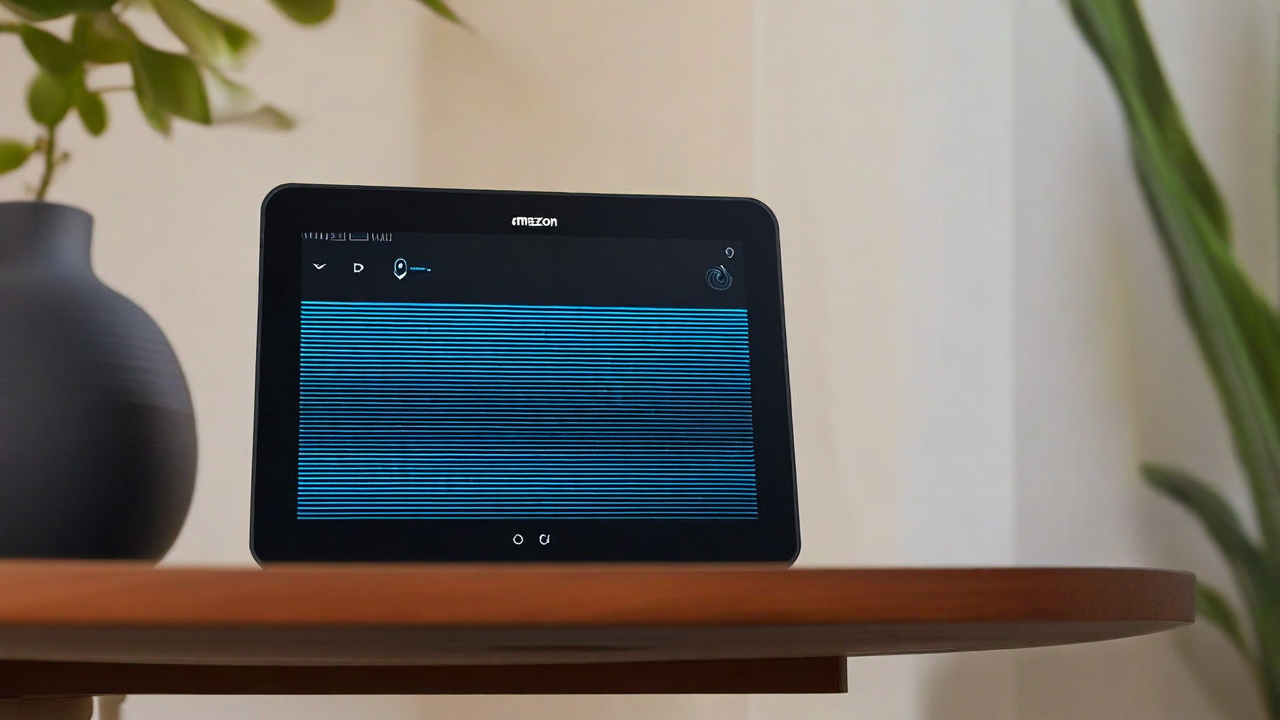

<i>It looks like your Echo Show's display is showing horizontal lines, which can be caused by a variety of issues. Here are some steps you can try to resolve this:

1. **Restart Your Echo Show:**
   - Unplug the power adapter from the device or the outlet.
   - Wait for 3 minutes.
   - Plug the power adapter back in.

2. **Verify Power Adapter:**
   - Ensure you are using the power adapter that came with your Echo Show.

If the issue persists after trying these steps, it might be a more complex hardware issue. In that case, I recommend contacting Amazon Customer Service for further assistance. They can provide more specific troubleshooting steps or arrange for a repair or replacement if necessary.

I hope this helps, and I'm here if you have any more questions!</i>

In [11]:
query = "The display on my echo show looks like this? What is the issue?"
image_path = "content/Troubleshooting/Pics/pic_horizontal_lines.png"
display(Image(filename=image_path, width=1000))

image_string, image_type = get_base64_encoded_image(image_path)
image_binary, image_type = prepare_image(image_path)

#response = prompt_with_rag(query=query, vectordb=vectordb, images=image_string, image_types=image_type)
response = prompt_with_rag(query=query, vectordb=vectordb, images_s=image_string, images_b=image_binary, image_types=image_type)
Markdown("<i>"+response+"</i>")

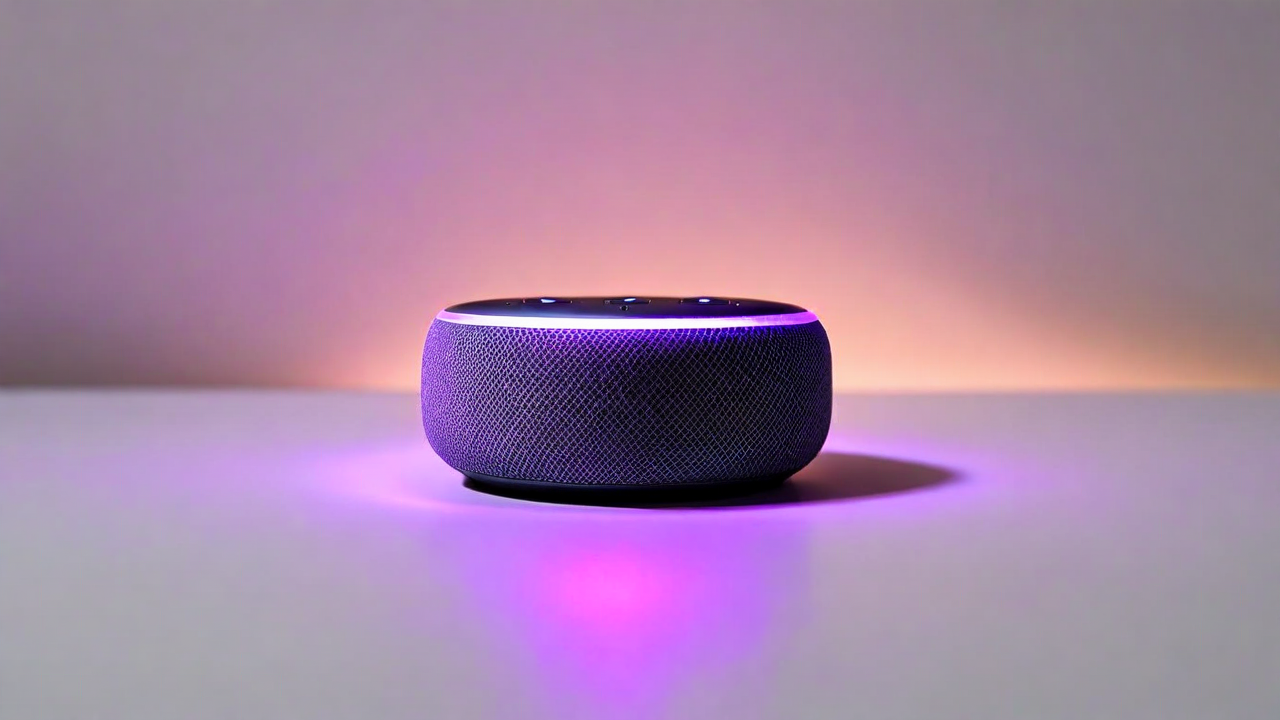

<i>Based on the context provided, if you are in the process of setting up your device, you might see an **orange light**. This indicates that your device is either in setup mode or trying to connect to the Internet. 

If you are still experiencing issues or have further questions, feel free to ask!</i>

In [12]:
query = """What color is the light in the device and what does it mean? \
I was just setting up the device."""

image_path = "content/Troubleshooting/Pics/pic_purple_light.png"
display(Image(filename=image_path, width=1000))

# prepare image for embedding
image_string, image_type = get_base64_encoded_image(image_path)
# prepare image for Invoking the model with Converse API
image_binary, image_type = prepare_image(image_path)

response = prompt_with_rag(query=query, vectordb=vectordb, images_s=image_string, images_b=image_binary, image_types=image_type)
Markdown("<i>"+response+"</i>")

<!-- Section Header -->
<div id="section5" style="border-left: 5px solid #3498DB; padding-left: 15px; margin: 40px 0 20px 0;">
    <h2 style="color: #2874A6;">5. Quizzes</h2>
</div>

Well done on completing the lab! Now, it's time for a brief knowledge assessment.

<!-- Challenge Box -->
<div style="background-color: #FEF9E7; border-left: 5px solid #F1C40F; padding: 15px; border-radius: 5px; margin: 20px 0; display: flex; align-items: flex-start;">
    <div style="flex: 0 0 60px; margin-right: 15px;">
        <img src="../mlu_utils/images/challenge.png" alt="Challenge" width="200" style="max-width: 100%; height: auto;">
    </div>
    <div style="flex: 1;">
        <h4 style="color: #B7950B; margin-top: 0;">Challenge: Try it Yourself!</h4>
        <p>Answer the following questions to test your understanding of using multimodal models for generating personalized and inclusive content.</p>
    </div>
</div>

In [13]:
from mlu_utils.quiz_questions import lab5b_question1, lab5b_question2

lab5b_question1.display()
lab5b_question2.display()

HTML(value='\n        <style>\n            .widget-button {\n                text-align: left !important;\n   …

HTML(value='\n        <style>\n            .widget-button {\n                text-align: left !important;\n   …

<div style="background-color: #EBF5FB; padding: 15px; border-radius: 5px; margin: 30px 0;">
    <h3 style="color: #2874A6; border-bottom: 1px solid #85C1E9; padding-bottom: 5px;">Conclusion</h3>
    <p>In this lab, you have:</p>
    <ul>
        <li>Created a RAG workflow for troubleshooting Echo devices</li>
        <li>Learned how to use multimodal embeddings for document retrieval</li>
        <li>Built a system that can process both text and image inputs for troubleshooting</li>
        <li>Tested the system with various queries and scenarios</li>
    </ul>
    <h4 style="color: #2874A6; margin-top: 15px;">Additional Resources</h4>
    <ul>
        <li><a href="https://docs.aws.amazon.com/bedrock/latest/userguide/nova-models.html">Amazon Nova Models</a></li>
        <li><a href="https://www.langchain.com/">LangChain Framework</a></li>
    </ul>
</div>

<p style="padding: 10px; border: 1px solid black;">
<img src="../mlu_utils/images/MLU-NEW-logo.png" alt="drawing" width="400"/> <br/>

# Thank you!